# Sentiment Analysis using NLP Pipeline

This project builds a machine learning model to classify movie reviews as positive or negative using Natural Language Processing (NLP).

The focus is on creating a **complete NLP pipeline**, including text preprocessing, vectorization, and model training.

---

## Workflow

1. Data Loading  
2. Text Preprocessing  
3. Text Vectorization (TF-IDF)  
4. Model Training  
5. Model Evaluation  

## Problem Statement

The goal of this project is to classify movie reviews into:

• Positive sentiment  
• Negative sentiment  

This is a binary classification problem using text data.

Challenges:

• Text preprocessing  
• High dimensionality  
• Feature extraction from text  

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df["sentiment"]=df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [7]:
x=df['review']
y=df['sentiment']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

# Text Preprocessing and Vectorization

In this stage, we prepare textual data for machine learning.

Raw text cannot be directly used by ML models, so we perform:

• Text cleaning  
• Removing noise (HTML, punctuation, stopwords)  
• Converting text into numerical features using TF-IDF  

TF-IDF helps represent text based on word importance rather than frequency.

In [8]:
import re
import string

def clean_text(text):
    text=text.lower()

    text=re.sub(r"<.*?>","",text)

    text=text.translate(str.maketrans("", "",string.punctuation))

    text=re.sub(r"\d+", "", text)
    return text

In [9]:
x_train=x_train.apply(clean_text)
x_test=x_test.apply(clean_text)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

## TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical features.

It assigns higher importance to words that:

• Appear frequently in a document  
• Are rare across all documents  

This helps the model focus on meaningful words rather than common ones like "the", "is", etc.

In [11]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)

model.fit(x_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred=model.predict(x_test_tfidf)

In [13]:
from sklearn.metrics import accuracy_score,classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8836
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In this stage, we converted raw text data into numerical features.

Steps performed:

• Cleaned text data  
• Removed noise and unwanted characters  
• Applied TF-IDF vectorization  
• Trained a Logistic Regression model  

This process enables machine learning models to understand and classify text data effectively.

# NLP Pipeline and Model Comparison

In this stage, we build a complete NLP pipeline and compare multiple models.

Instead of manually applying preprocessing and vectorization, we integrate everything into a **Pipeline**.

This approach ensures:

• Clean and reusable code  
• No data leakage  
• Easy deployment  

We also compare different models to identify the best-performing algorithm.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_lr=Pipeline([
    ("tfidf",TfidfVectorizer(
        max_features=5000,
        stop_words='english'
    )),
    ('model',LogisticRegression(max_iter=1000))
])

In [15]:
pipeline_lr.fit(x_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('model', LogisticRegression(max_iter=1000))])

In [16]:
y_pred_lr=pipeline_lr.predict(x_test)

from sklearn.metrics import classification_report,accuracy_score

print('Logistic Regression Accuracy:',accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.8836
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [17]:
from sklearn.naive_bayes import MultinomialNB

pipeline_nb=Pipeline([
    ('tfidf',TfidfVectorizer(
        max_features=5000,
        stop_words='english'
    )),
    ('model',MultinomialNB())
])

pipeline_nb.fit(x_train,y_train)

y_pred_nb=pipeline_nb.predict(x_test)

print('Naive Bayes Accuracy:',accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))

Naive Bayes Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [18]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf=Pipeline([
    ('tfidf',TfidfVectorizer(
        max_features=5000,
        stop_words='english'
    )),
    ('model',RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(x_train,y_train)

y_pred_rf=pipeline_rf.predict(x_test)

print('Random Forest Accuracy:',accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy: 0.8473
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.83      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## Model Performance Analysis

The Logistic Regression model achieved the highest accuracy of **88.36%**, outperforming Naive Bayes and Random Forest.

Key observations:

• Logistic Regression performs best on high-dimensional text data  
• Naive Bayes provides good performance with faster training  
• Random Forest struggles due to sparse feature representation  

This confirms that linear models are highly effective for TF-IDF based text classification tasks.

# Advanced Evaluation and Model Insights

In this stage, we perform deeper evaluation of the NLP model and extract insights from it.

We use:

• Confusion Matrix  
• ROC Curve  
• Feature importance (top words)  

These techniques help us understand how the model makes predictions and what words influence sentiment.

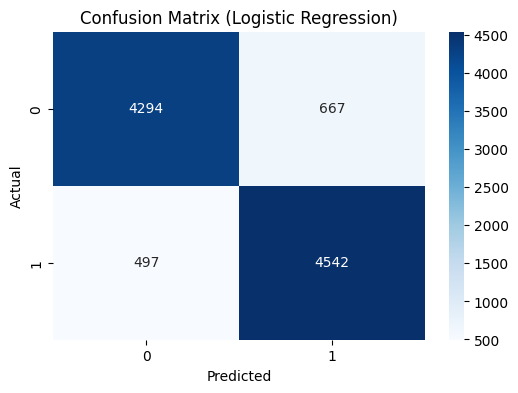

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Confusion Matrix Insight

The confusion matrix shows how many reviews were correctly and incorrectly classified.

• True Positives → Correct positive predictions  
• True Negatives → Correct negative predictions  
• False Positives → Incorrect positive predictions  
• False Negatives → Missed predictions  

This helps identify where the model makes mistakes.

In [20]:
from sklearn.metrics import roc_auc_score,roc_curve

lr_probs=pipeline_lr.predict_proba(x_test)[:,1]

fpr,tpr,thresholds=roc_curve(y_test,lr_probs)
auc_score=roc_auc_score(y_test,lr_probs)

print('ROC-AUC Score:',auc_score)

ROC-AUC Score: 0.9548348521524048


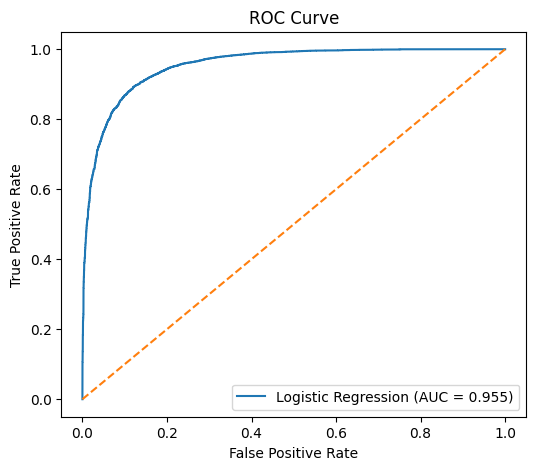

In [21]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % auc_score)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## ROC Curve Insight

The ROC curve evaluates how well the model separates positive and negative sentiments.

An AUC score close to 1 indicates strong classification performance.

This confirms that the model effectively distinguishes between positive and negative reviews.

In [22]:
feature_names = pipeline_lr.named_steps["tfidf"].get_feature_names_out()
coefficients = pipeline_lr.named_steps["model"].coef_[0]

top_positive = np.argsort(coefficients)[-10:]

top_negative = np.argsort(coefficients)[:10]

print("Top Positive Words:")
print(feature_names[top_positive])

print("\nTop Negative Words:")
print(feature_names[top_negative])

Top Positive Words:
['hilarious' 'loved' 'brilliant' 'favorite' 'amazing' 'perfect'
 'wonderful' 'best' 'excellent' 'great']

Top Negative Words:
['worst' 'waste' 'awful' 'bad' 'boring' 'poor' 'terrible' 'poorly' 'dull'
 'worse']


## Important Words Analysis

The model assigns weights to words based on their importance.

Positive words (e.g., "excellent", "amazing") contribute to positive predictions.

Negative words (e.g., "worst", "boring") contribute to negative predictions.

This helps interpret how the model understands sentiment.

# Final Model Selection and Conclusion

In this final stage, we summarize model performance, extract key insights, and present the final conclusions.

We select the best-performing model and highlight how it can be used in real-world applications.

## Final Model Selection

After evaluating multiple models, **Logistic Regression with TF-IDF** was selected as the final model.

Reasons:

• Highest accuracy (~88.36%)  
• Performs well on high-dimensional text data  
• Fast and efficient  
• Interpretable  

This model provides the best balance between performance and simplicity.

In [23]:
from sklearn.metrics import classification_report

y_pred_final=pipeline_lr.predict(x_test)

print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [24]:
from sklearn.metrics import accuracy_score

final_accuracy=accuracy_score(y_test,y_pred_final)
print("Final accuracy:",final_accuracy)

Final accuracy: 0.8836


## Model Performance Summary

Final Model: Logistic Regression (TF-IDF)

• Accuracy: **88.36%**  
• Balanced precision and recall  
• Strong performance on both classes  

The model demonstrates reliable sentiment classification performance.

## Key Learnings

• Text data requires preprocessing and vectorization  
• TF-IDF is effective for feature extraction  
• Logistic Regression performs well for text classification  
• Pipelines simplify the ML workflow  

This project demonstrates how NLP techniques can be applied to real-world problems.

# Project Conclusion

This project successfully built an NLP pipeline for sentiment analysis.

Key achievements:

• Cleaned and preprocessed text data  
• Applied TF-IDF vectorization  
• Built machine learning pipelines  
• Compared multiple models  
• Extracted insights from text  

The final model achieved strong performance and can be used for real-world sentiment analysis tasks.

In [25]:
import joblib

joblib.dump(pipeline_lr, "sentiment_model.pkl")

['sentiment_model.pkl']